In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import math
import soundfile as sf
import random
from tqdm.notebook import tqdm as tqdm

In [3]:
pickle_file = "beta_zero.pth"
beta  = "0"

In [4]:
device="cpu" 

In [5]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [6]:
def sin(t):
    return np.sin(t)

def saw(t):
    return ( ((t-np.pi)/(2*np.pi))%1 - .5) *2

def square(t):
    return np.sign(np.sin(t))

def tri(t):
    sw = saw(t+np.pi/2)*2
    return sw * np.sign(sw)- 1

In [7]:
def create_waveforms(fn=sin, fs=512, duration=1024, period=440, phase=0, amplitude=1):
    period = np.array(period)
    period = np.reshape(period, (period.size, 1))

    phase = np.array(phase)
    phase = np.reshape(phase, (phase.size, 1))

    amplitude = np.array(amplitude)
    amplitude = np.reshape(amplitude, (amplitude.size, 1))

    t = (np.arange(0, duration, 1)/fs)[None,:]
    x = amplitude * fn(2*np.pi*(phase + t*period))
    return x, t

In [8]:
input_length = 256

np.random.seed(0)

# convert it into np.arrange instead of hardcoding
periods_train = [
    261.63, 277.18, 293.66, 311.13, 329.63, 349.23, 369.99, 392.0, 415.3, 440.0,
    466.16, 493.88, 523.25, 554.37, 587.33, 622.25, 659.25, 698.46, 739.99, 783.99,
    830.61, 880.0, 932.33, 987.77, 1046.5, 1108.73, 1174.66, 1244.51, 1318.51, 1396.91,
    1479.98, 1567.98, 1661.22, 1760.0, 1864.66, 1975.53
]
n_samples_train = len(periods_train)

half_index = len(periods_train) // 2
periods_sin = periods_train[:half_index]
periods_saw = periods_train[half_index:]

var_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)
var_triangle, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train, amplitude=1)


x_sin, _ = create_waveforms(fn=sin, fs=22050, duration=input_length, phase=0, period=periods_train[0*n_samples_train//4:1*n_samples_train//4], amplitude=1)
x_saw, _ = create_waveforms(fn=saw, fs=22050, duration=input_length, phase=0, period=periods_train[1*n_samples_train//4:2*n_samples_train//4], amplitude=1)
x_tri, _ = create_waveforms(fn=tri, fs=22050, duration=input_length, phase=0, period=periods_train[2*n_samples_train//4:3*n_samples_train//4], amplitude=1)
x_square, _ = create_waveforms(fn=square, fs=22050, duration=input_length, phase=0, period=periods_train[3*n_samples_train//4:4*n_samples_train//4], amplitude=1)

var_all_shape = torch.tensor(np.concatenate([x_sin,x_square, x_tri, x_saw], axis=0), dtype=torch.float32)

var_tri_saw = torch.tensor(np.concatenate([x_tri, x_saw], axis=0), dtype=torch.float32)

 # x_square, x_tri,

In [15]:
var_sin.shape

(9, 256)

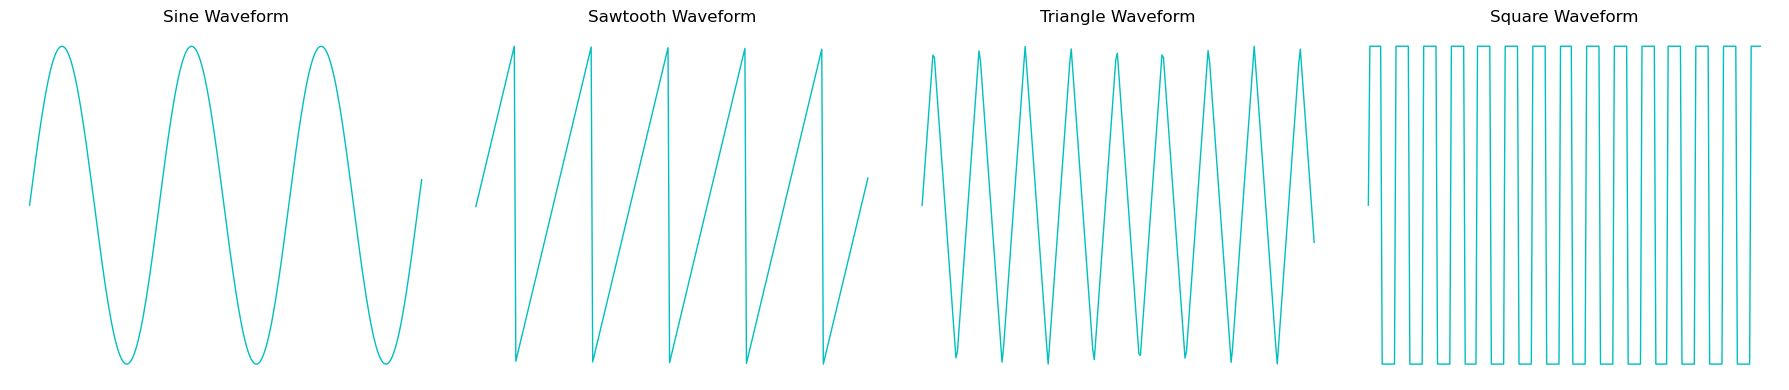

In [9]:
plt.figure(figsize=(18, 4))  # Set figure size for landscape mode (wide format)

# Plot each waveform side by side
plt.subplot(1, 4, 1)
plt.plot(x_sin[0],color='c', lw=1)
plt.title('Sine Waveform')
plt.axis('off')  

plt.subplot(1, 4, 2)
plt.plot(x_saw[0],color='c', lw=1)
plt.title('Sawtooth Waveform')
plt.axis('off')  


plt.subplot(1, 4, 3)
plt.plot(x_tri[0],color='c', lw=1)
plt.title('Triangle Waveform')
plt.axis('off')  


plt.subplot(1, 4, 4)
plt.plot(x_square[0],color='c', lw=1)
plt.title('Square Waveform')
plt.axis('off')  

plt.savefig(r"waves.png")
plt.tight_layout()
plt.show()


# Sine Wav Interpolation

In [10]:
var_sin.shape
epsilon = 1e-10

In [11]:
# scale_tensor = var_freq.flatten()
# sf.write(f"waveforms/var_shape.wav",scale_tensor,22050)

In [12]:
fft_sin = np.fft.fft(var_sin, axis=1)
power_spectrum_sin = np.abs(fft_sin) ** 2
frequencies_sin = np.fft.fftfreq(input_length, 1/22050)

fft_sqaure = np.fft.fft(var_square, axis=1)
power_spectrum_square = np.abs(fft_sqaure) ** 2
frequencies_square = np.fft.fftfreq(input_length, 1/22050)

fft_saw = np.fft.fft(var_saw, axis=1)
power_spectrum_saw = np.abs(fft_saw) ** 2
frequencies_saw = np.fft.fftfreq(input_length, 1/22050)

fft_tri = np.fft.fft(var_triangle, axis=1)
power_spectrum_tri = np.abs(fft_tri) ** 2
frequencies_tri = np.fft.fftfreq(input_length, 1/22050)



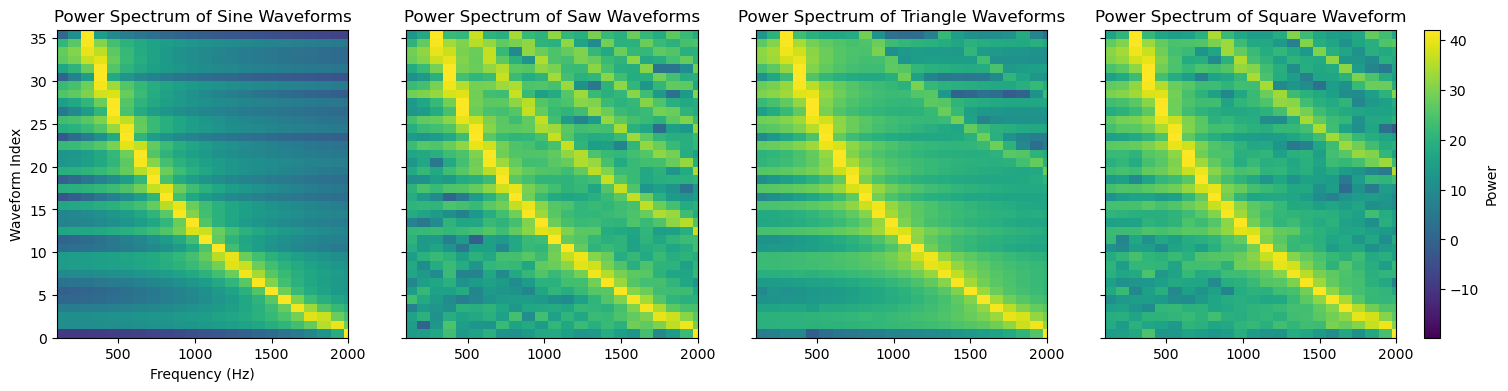

In [13]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

# Plot each power spectrum
cax1 = axs[0].imshow(10 * np.log10(power_spectrum_sin[:, :input_length // 2] + epsilon), aspect='auto', cmap='viridis',
                     extent=[frequencies_sin[0], frequencies_sin[input_length // 2 - 1], 0, n_samples_train])
axs[0].set_title('Power Spectrum of Sine Waveforms')
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Waveform Index')
axs[0].set_xlim(100, 2000)

cax2 = axs[1].imshow(10 * np.log10(power_spectrum_saw[:, :input_length // 2] + epsilon), aspect='auto', cmap='viridis',
                     extent=[frequencies_saw[0], frequencies_saw[input_length // 2 - 1], 0, n_samples_train])
axs[1].set_title('Power Spectrum of Saw Waveforms')
axs[1].set_xlim(100, 2000)

cax3 = axs[2].imshow(10 * np.log10(power_spectrum_tri[:, :input_length // 2] + epsilon), aspect='auto', cmap='viridis',
                     extent=[frequencies_tri[0], frequencies_tri[input_length // 2 - 1], 0, n_samples_train])
axs[2].set_title('Power Spectrum of Triangle Waveforms')
axs[2].set_xlim(100, 2000)

cax4 = axs[3].imshow(10 * np.log10(power_spectrum_square[:, :input_length // 2] + epsilon), aspect='auto', cmap='viridis',
                     extent=[frequencies_square[0], frequencies_square[input_length // 2 - 1], 0, n_samples_train])
axs[3].set_title('Power Spectrum of Square Waveform')
axs[3].set_xlim(100, 2000)

# Create a common color bar
cbar = fig.colorbar(cax1, ax=axs, orientation='vertical', pad=0.02, fraction=0.02)
cbar.set_label('Power')

# Adjust layout to prevent overlap

# Optionally save the figure
plt.savefig(r"spec_waves.png")

# Display the figure
plt.show()

In [198]:
# import matplotlib.pyplot as plt

# # Create a single figure
# plt.figure(figsize=(18, 4))  # Set figure size for landscape mode (wide format)

# # Plot each power spectrum side by side
# plt.subplot(1, 4, 1)
# plt.plot(frequencies_tri[:input_length // 2], power_spectrum_sin[0, :input_length // 2])
# plt.title('Sine Wave FFT')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Power')
# plt.axis('off')  


# plt.subplot(1, 4, 2)
# plt.plot(frequencies_tri[:input_length // 2], power_spectrum_saw[0, :input_length // 2])
# plt.title('Saw Wave FFT')
# plt.axis('off')  


# plt.subplot(1, 4, 3)
# plt.plot(frequencies_tri[:input_length // 2], power_spectrum_tri[0, :input_length // 2])
# plt.title('Triangle Wave FFT')
# plt.axis('off')  


# plt.subplot(1, 4, 4)
# plt.plot(frequencies_tri[:input_length // 2], power_spectrum_square[0, :input_length // 2])
# plt.title('Square Wave FFT')
# plt.axis('off')  


# # Adjust layout to prevent overlap
# plt.tight_layout()

# # Optionally save the figure
# plt.savefig(r"freq_waves.png")

# # Display the figure
# plt.show()


In [199]:
# plt.figure(figsize=(12, 8))
# plt.imshow(var_sin, aspect='auto', cmap='viridis')
# plt.colorbar(label='Amplitude')
# plt.title('Waveforms Matrix')
# plt.xlabel('Sample')
# plt.ylabel('Waveform Index')
# plt.show()

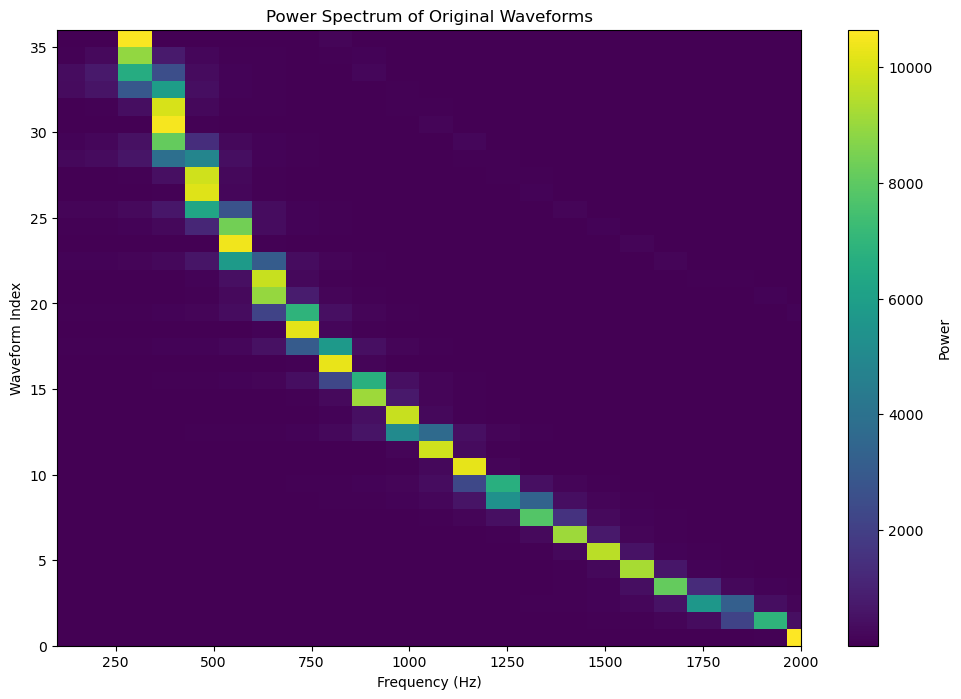

In [125]:
# plt.figure(figsize=(12, 8))
# plt.imshow(power_spectrum_tri[:, :input_length // 2], aspect='auto', cmap='viridis',
#            extent=[frequencies_tri[0], frequencies_tri[input_length // 2 - 1], 0, n_samples_train])
# plt.colorbar(label='Power')
# plt.title('Power Spectrum of Original Waveforms')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Waveform Index')
# plt.xlim(100,2000)
# plt.show()

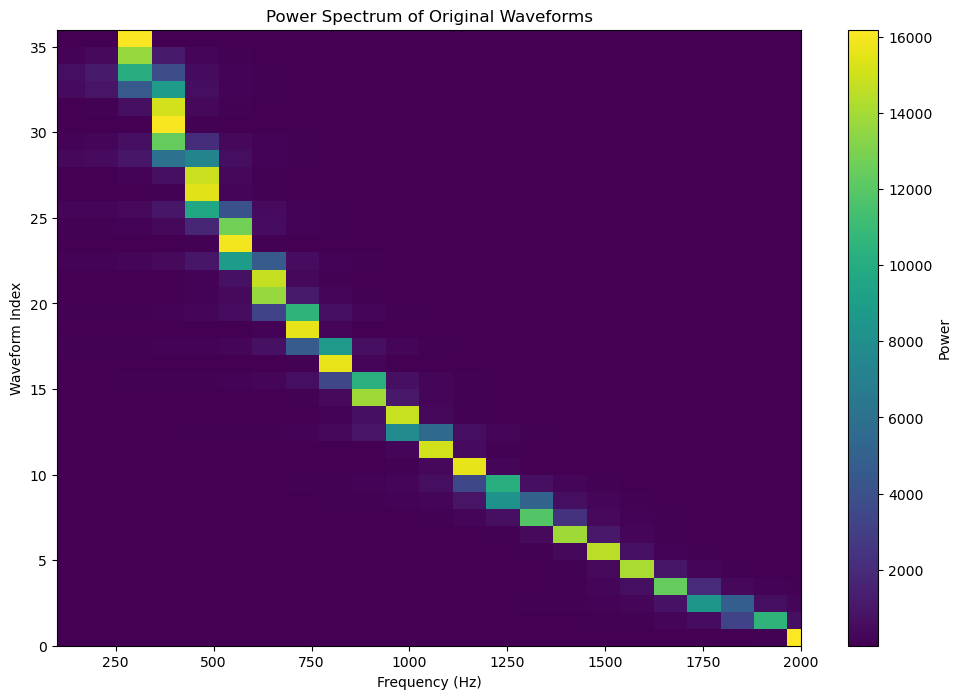

In [126]:
# plt.figure(figsize=(12, 8))
# plt.imshow(power_spectrum_sin[:, :input_length // 2], aspect='auto', cmap='viridis',
#            extent=[frequencies_sin[0], frequencies_sin[input_length // 2 - 1], 0, n_samples_train])
# plt.colorbar(label='Power')
# plt.title('Power Spectrum of Original Waveforms')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Waveform Index')
# plt.xlim(100,2000)
# plt.show()

In [127]:
class VAE(torch.nn.Module):
    def __init__(self, input_dim=512, latent_dim=2, hidden_dims=[128, 64, 36]):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1],hidden_dims[2]),
            torch.nn.Tanh(),
            
        )

        self.z_mean = torch.nn.Linear(hidden_dims[2], latent_dim)
        self.z_log_var = torch.nn.Linear(hidden_dims[2], latent_dim)


        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, hidden_dims[2]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[2], hidden_dims[1]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[1], hidden_dims[0]),
            torch.nn.Tanh(),
            torch.nn.Linear(hidden_dims[0], input_dim),
        )


    def reparameterize(self, z_mu, z_log_var):
        device = z_mu.device
        # Sampling the eps from the standard multivariate normal distribution in each forward pass
        eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(device)
        # reparameterized_mean = mean_vector + random noise(eps) + log variance
        z = z_mu + eps * torch.exp(z_log_var / 2.0)
        return z

    def forward(self, x):
        x = self.encoder(x)
        z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decoder(encoded)
        return encoded,z_mean,z_log_var,decoded

In [128]:
autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
autoencoder.load_state_dict(torch.load(pickle_file))

<All keys matched successfully>

In [129]:
x = autoencoder.encoder(torch.Tensor(var_sin))
z_mean, z_log_var = autoencoder.z_mean(x), autoencoder.z_log_var(x)
encoded = autoencoder.reparameterize(z_mean, z_log_var)

In [130]:
output = autoencoder.decoder(encoded).detach().numpy()

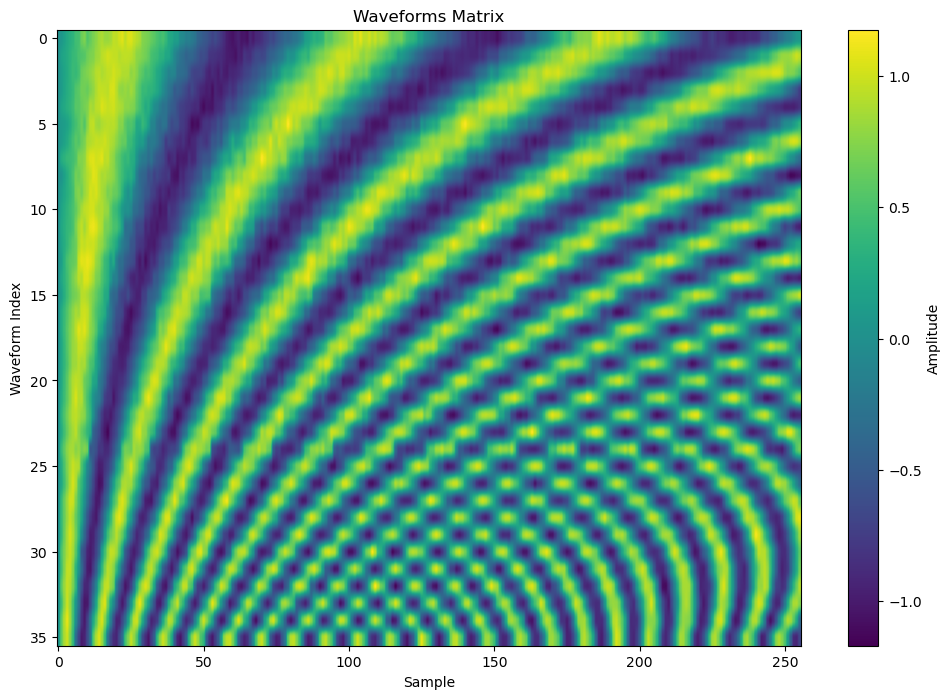

In [131]:
plt.figure(figsize=(12, 8))
plt.imshow(output, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('Waveforms Matrix')
plt.xlabel('Sample')
plt.ylabel('Waveform Index')
plt.show()

In [132]:
fft_sin = np.fft.fft(output, axis=1)
power_spectrum = np.abs(fft_sin) ** 2
frequencies = np.fft.fftfreq(input_length, 1/22050)
power_spectrum.shape

(36, 256)

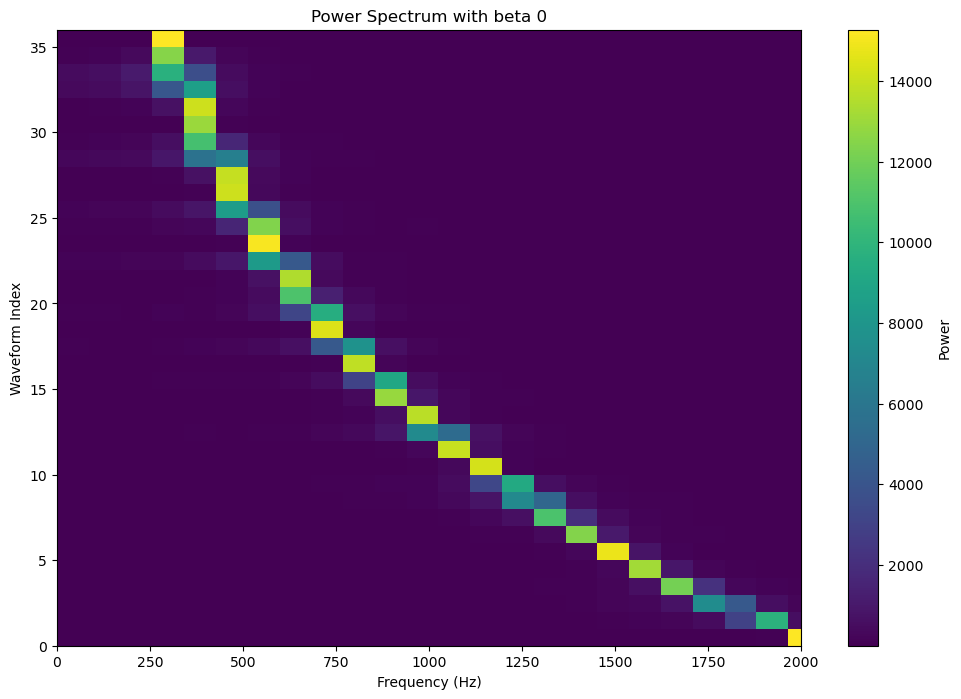

In [133]:
plt.figure(figsize=(12, 8))
plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title(f'Power Spectrum with beta {beta}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(0,2000)
plt.show()

In [134]:
# scale_tensor = output.flatten()
# sf.write(f"waveforms/beta_zero.wav",scale_tensor,22050)

In [135]:
# var_freq.shape

In [136]:
# averaged_array = np.mean(var_freq, axis=0, keepdims=True)

In [137]:
# fft_sin = np.fft.fft(averaged_array, axis=1)
# power_spectrum = np.abs(fft_sin) ** 2
# frequencies = np.fft.fftfreq(input_length, 1/22050)
# power_spectrum.shape

In [138]:
# plt.figure(figsize=(12, 8))
# plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
#            extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
# plt.colorbar(label='Power')
# plt.title('Power Spectrum of mean')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Waveform Index')
# plt.xlim(100,2000)
# plt.show()

# Sin + Saw Wav

In [205]:
var_tri_saw.shape

torch.Size([18, 256])

In [206]:
# scale_tensor = var_freq.flatten()
# sf.write(f"waveforms/var_shape.wav",scale_tensor,22050)

In [207]:
fft_sin = np.fft.fft(var_tri_saw, axis=1)
power_spectrum = np.abs(fft_sin) ** 2
frequencies = np.fft.fftfreq(input_length, 1/22050)
power_spectrum.shape

(18, 256)

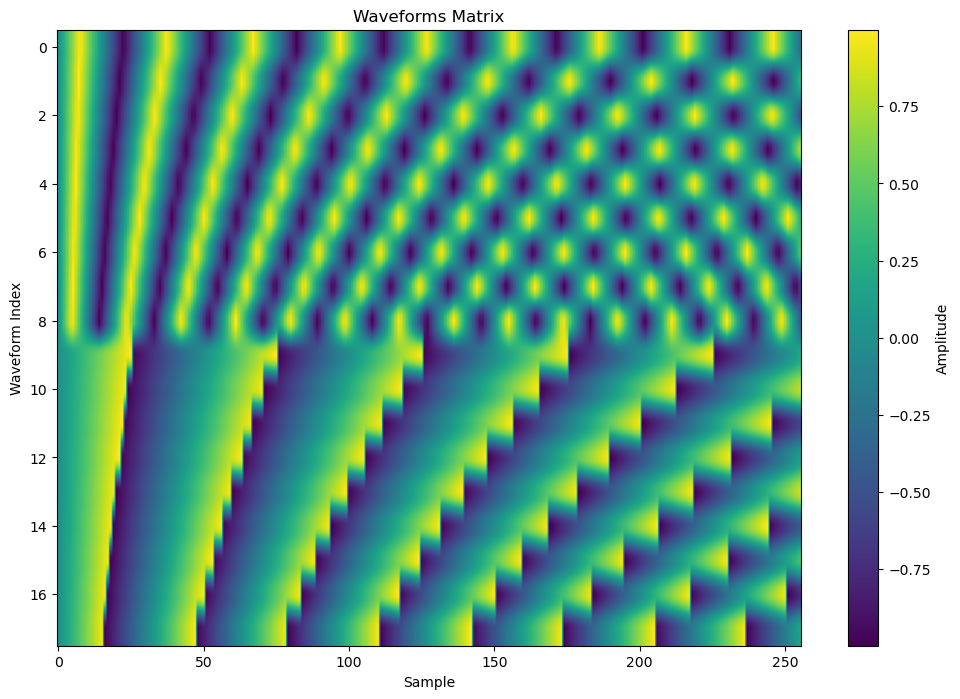

In [208]:
plt.figure(figsize=(12, 8))
plt.imshow(var_tri_saw, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('Waveforms Matrix')
plt.xlabel('Sample')
plt.ylabel('Waveform Index')
plt.show()

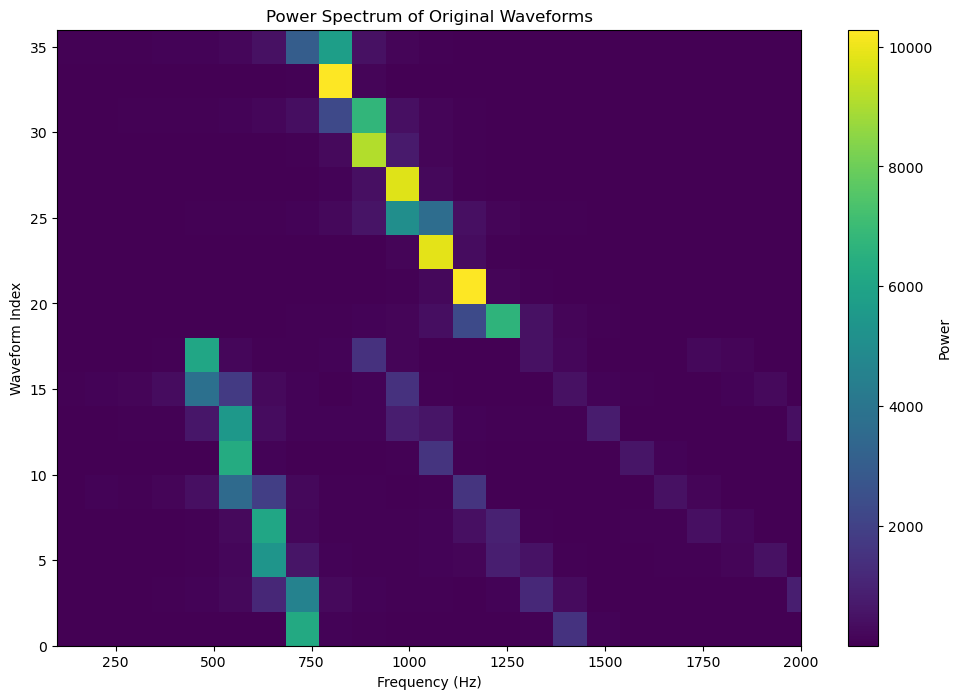

In [209]:
plt.figure(figsize=(12, 8))
plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title('Power Spectrum of Original Waveforms')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(100,2000)
plt.show()

In [210]:
# autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
# autoencoder.load_state_dict(torch.load(f"beta_zero.pth"))

In [211]:
x = autoencoder.encoder(torch.Tensor(var_tri_saw))
z_mean, z_log_var = autoencoder.z_mean(x), autoencoder.z_log_var(x)
encoded = autoencoder.reparameterize(z_mean, z_log_var)

In [212]:
output = autoencoder.decoder(encoded).detach().numpy()

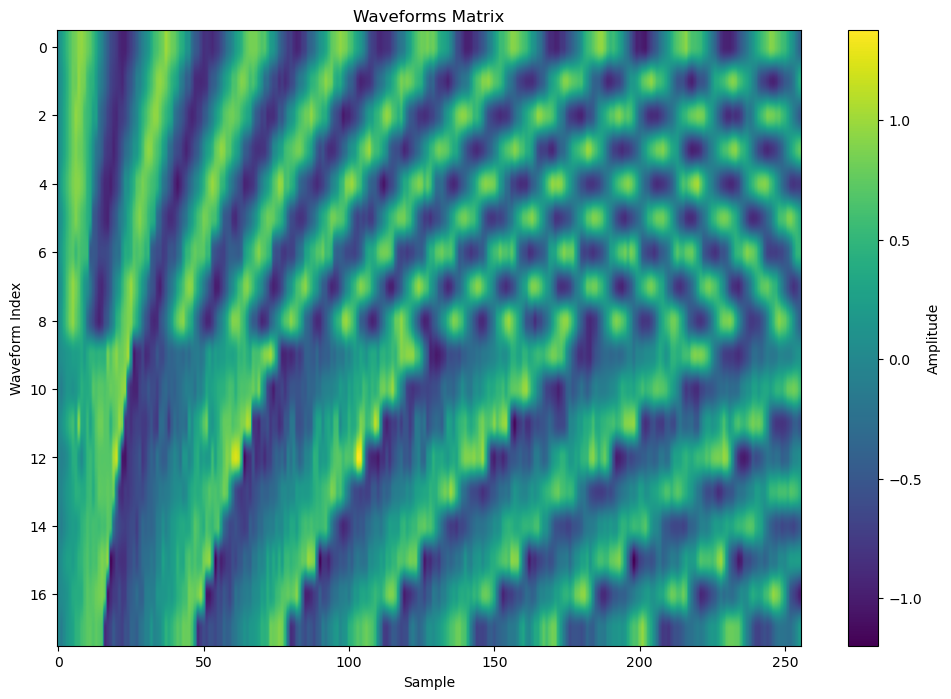

In [213]:
plt.figure(figsize=(12, 8))
plt.imshow(output, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('Waveforms Matrix')
plt.xlabel('Sample')
plt.ylabel('Waveform Index')
plt.show()

In [214]:
fft_sin = np.fft.fft(output, axis=1)
power_spectrum = np.abs(fft_sin) ** 2
frequencies = np.fft.fftfreq(input_length, 1/22050)
power_spectrum.shape

(18, 256)

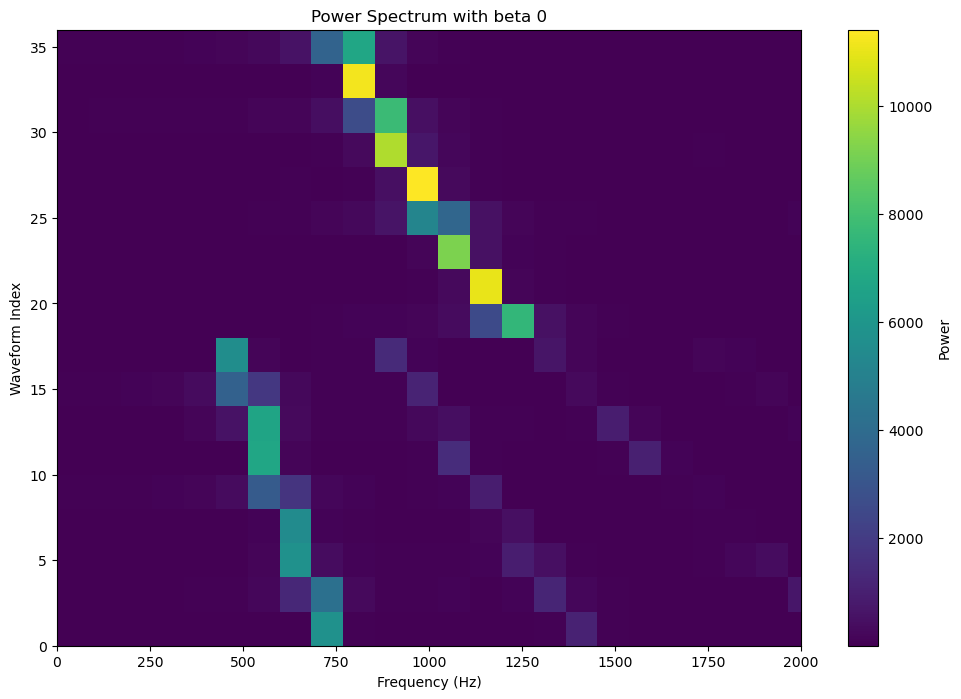

In [215]:
plt.figure(figsize=(12, 8))
plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title(f'Power Spectrum with beta {beta}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(0,2000)
plt.show()

# Sin + Triangle + Saw + Square

In [161]:
var_all_shape.shape

torch.Size([36, 256])

In [162]:
# scale_tensor = var_freq.flatten()
# sf.write(f"waveforms/var_shape.wav",scale_tensor,22050)

In [163]:
fft_sin = np.fft.fft(var_all_shape, axis=1)
power_spectrum = np.abs(fft_sin) ** 2
frequencies = np.fft.fftfreq(input_length, 1/22050)
power_spectrum.shape

(36, 256)

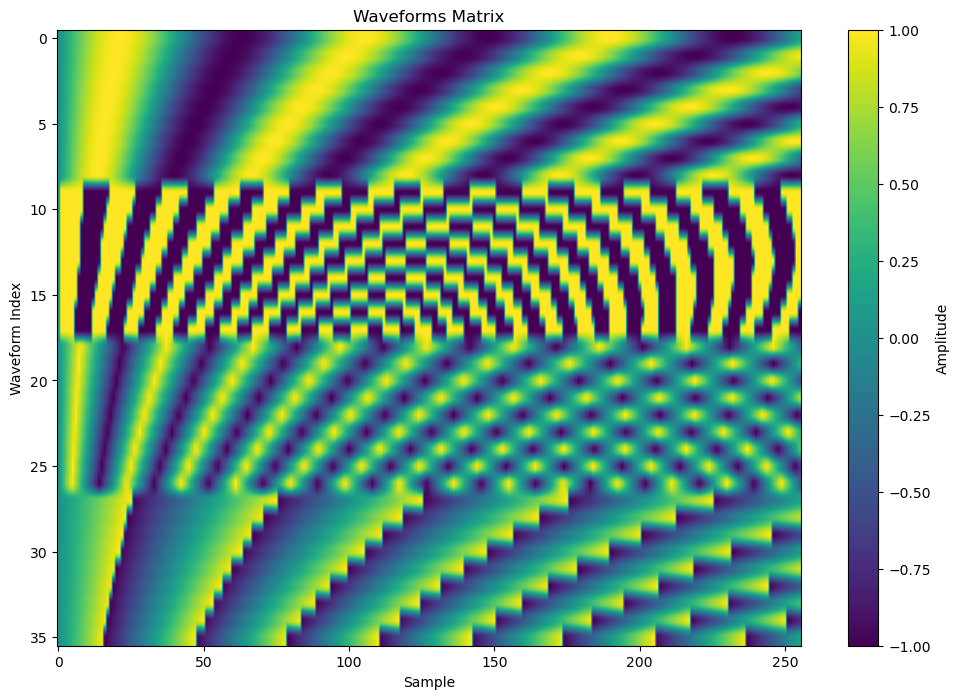

In [164]:
plt.figure(figsize=(12, 8))
plt.imshow(var_all_shape, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('Waveforms Matrix')
plt.xlabel('Sample')
plt.ylabel('Waveform Index')
plt.show()

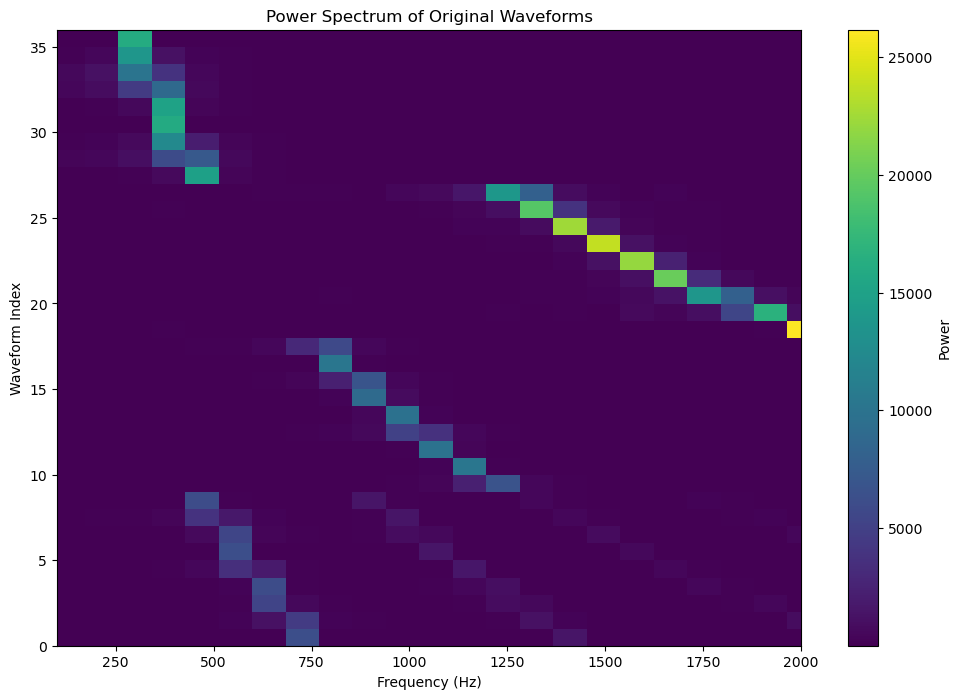

In [165]:
plt.figure(figsize=(12, 8))
plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title('Power Spectrum of Original Waveforms')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(100,2000)
plt.show()

In [166]:
# autoencoder = VAE(input_dim=input_length, latent_dim=2, hidden_dims=[256,128,64])
# autoencoder.load_state_dict(torch.load(f"beta_zero.pth"))

In [167]:
x = autoencoder.encoder(torch.Tensor(var_all_shape))
z_mean, z_log_var = autoencoder.z_mean(x), autoencoder.z_log_var(x)
encoded = autoencoder.reparameterize(z_mean, z_log_var)

In [168]:
output = autoencoder.decoder(encoded).detach().numpy()

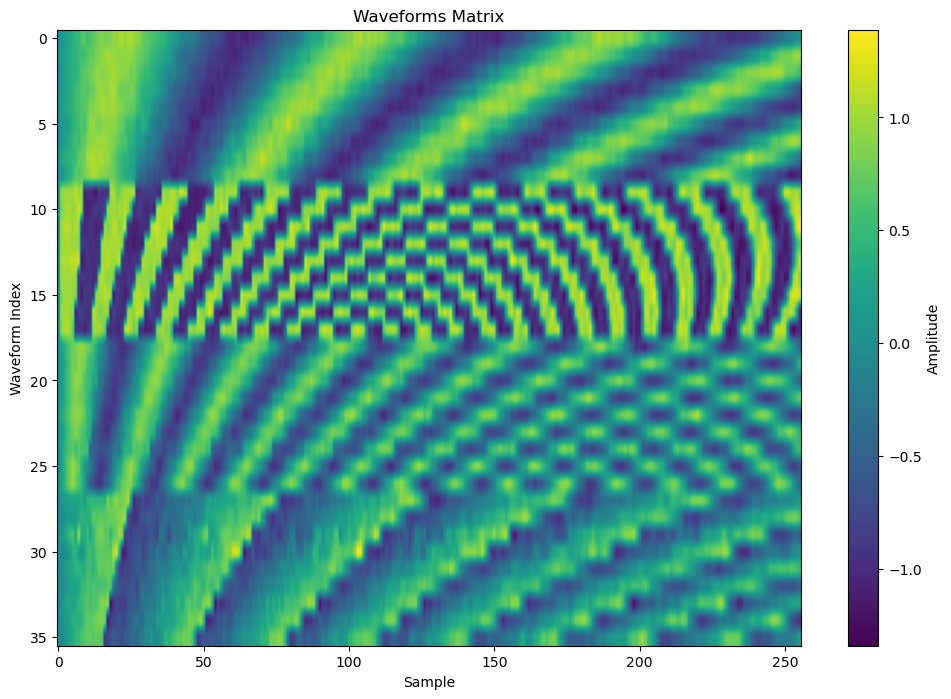

In [169]:
plt.figure(figsize=(12, 8))
plt.imshow(output, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.title('Waveforms Matrix')
plt.xlabel('Sample')
plt.ylabel('Waveform Index')
plt.show()

In [170]:
fft_sin = np.fft.fft(output, axis=1)
power_spectrum = np.abs(fft_sin) ** 2
frequencies = np.fft.fftfreq(input_length, 1/22050)
power_spectrum.shape

(36, 256)

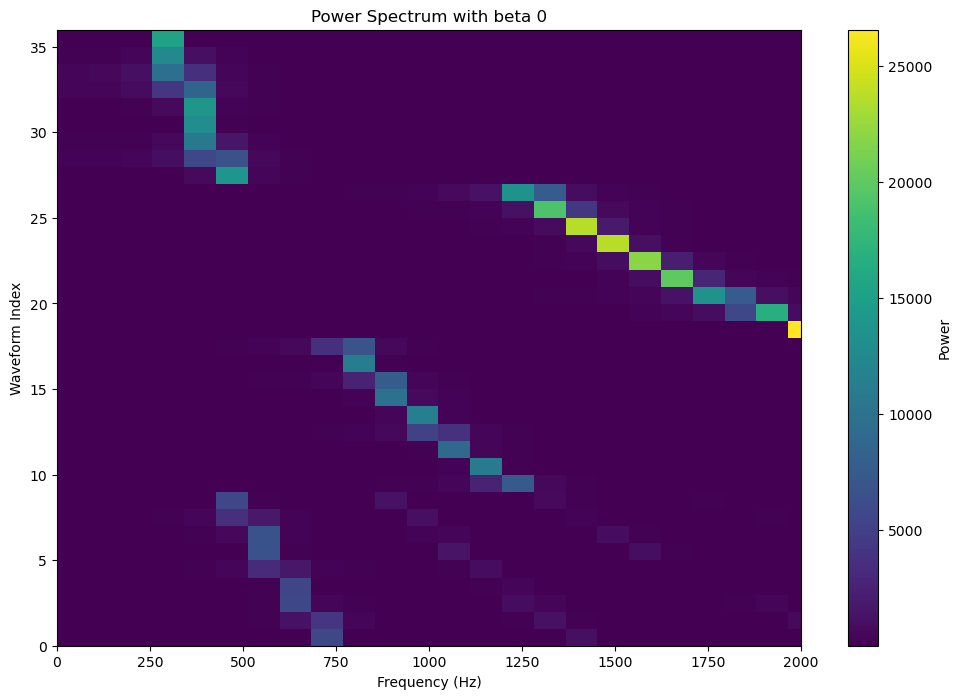

In [171]:
plt.figure(figsize=(12, 8))
plt.imshow(power_spectrum[:, :input_length // 2], aspect='auto', cmap='viridis',
           extent=[frequencies[0], frequencies[input_length // 2 - 1], 0, n_samples_train])
plt.colorbar(label='Power')
plt.title(f'Power Spectrum with beta {beta}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Waveform Index')
plt.xlim(0,2000)
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot each spectrogram
axs[0, 0].imshow(spectrogram_1, aspect='auto', cmap='viridis')
axs[0, 0].set_title("Spectrogram 1")

axs[0, 1].imshow(spectrogram_2, aspect='auto', cmap='viridis')
axs[0, 1].set_title("Spectrogram 2")

axs[1, 0].imshow(spectrogram_3, aspect='auto', cmap='viridis')
axs[1, 0].set_title("Spectrogram 3")

axs[1, 1].imshow(spectrogram_4, aspect='auto', cmap='viridis')
axs[1, 1].set_title("Spectrogram 4")

# Adjust layout and show
plt.tight_layout()
plt.show()